# 02 - Medical Dictionary Creation (Hybrid Approach: UMLS + LLM)

In this notebook, we build a robust semantic medical vocabulary for our Sparse Autoencoder.
To ensure scientific validity (avoiding hallucinations of non-existent medical terms), the pipeline follows a three-stage approach:
1. **Dynamic Extraction:** Pathological classes are extracted directly from the NIH dataset metadata.
2. **Semantic Ground Truth (UMLS API):** Classes are sent to NIH APIs (UMLS Terminology Services) to extract certified synonyms from ontologies like SNOMED CT.
3. **Contextual Generation (LLM):** Certified synonyms are passed to a quantized LLM (Zephyr/Llama) to generate realistic radiological report phrases, optimizing the subsequent text embedding phase.

## Visual Feature Extraction (Vision-Language Alignment)

**Note on the Dataset (NIH Chest X-ray14 - 10k Subset):**
For this project, we chose not to process the entire original NIH dataset (112,120 images, ~42 GB) to comply with memory and execution constraints (timeouts) on Google Colab.
We use a stratified and balanced subset of 10,000 samples (`g-ronimo/NIH-Chest-X-ray-dataset_10k`), derived directly from the official data. This volume is statistically sufficient for our *proof-of-concept*: our goal is not to train a visual classifier from scratch, but to allow the loss function of a *Sparse Autoencoder* (SAE) to converge by leveraging a pre-trained latent space (PubMed CLIP).

In [1]:
# Setup and installation of required libraries
!pip install -q transformers accelerate bitsandbytes datasets huggingface_hub requests python-dotenv


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 17.1 MB/s eta 0:00:00


In [3]:
import sys
import os

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    from google.colab import userdata
    drive.mount('/content/drive')
    save_dir = '/content/drive/MyDrive/xai-project5/results/02_dictionary_creation'

    # Reading secrets from Google Colab
    UMLS_API_KEY = userdata.get('UMLS_API_KEY')
    HF_TOKEN = userdata.get('HF_TOKEN')
else:
    from dotenv import load_dotenv
    load_dotenv() # Load from .env file in the project folder

    save_dir = os.path.abspath(os.path.join('..', 'results', '02_dictionary_creation'))
    UMLS_API_KEY = os.getenv('UMLS_API_KEY')
    HF_TOKEN = os.getenv('HF_TOKEN')

os.makedirs(save_dir, exist_ok=True)
print(f"Save directory configured at: {save_dir}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Save directory configured at: /content/drive/MyDrive/xai-project5/results/02_dictionary_creation


## 1. Dynamic Label Extraction
Instead of hardcoding the categories (e.g., "Cardiomegaly", "Atelectasis"), we load the Hugging Face dataset metadata to programmatically extract the original classes on which the dataset was annotated.

In [4]:
from datasets import load_dataset

print("Reading metadata from the original dataset...")
# We load only the structure, without downloading images again (streaming or empty split)
dataset_meta = load_dataset("g-ronimo/NIH-Chest-X-ray-dataset_10k", split="train")

# Dynamic label extraction (the 14 original classes)
dynamic_labels = dataset_meta.features['labels'].feature.names

# We remove the "No Finding" class if we only want to focus on pathologies
dynamic_labels = [label for label in dynamic_labels if label != "No Finding"]

print(f"Extracted {len(dynamic_labels)} pathological classes directly from metadata:")
print(dynamic_labels)


Reading metadata from the original dataset...


README.md:   0%|          | 0.00/830 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/457M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/153M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7500 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2500 [00:00<?, ? examples/s]

Extracted 14 pathological classes directly from metadata:
['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration', 'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax', 'Consolidation', 'Edema', 'Emphysema', 'Fibrosis', 'Pleural_Thickening', 'Hernia']


## 2. UMLS API Query (Semantic Ground Truth)
We define functions to communicate with the UMLS Terminology Services portal.
- `get_umls_cui`: Finds the exact Concept Unique Identifier (CUI) for the pathology.
- `get_umls_synonyms`: Extracts all official synonyms associated with that CUI, filtering out noise.

In [8]:
import os
import requests
import json

BASE_URL = "https://uts-ws.nlm.nih.gov/rest"

def get_umls_cui(term: str, api_key: str) -> str:
    endpoint = f"{BASE_URL}/search/current"
    params = {
        "string": term,
        "apiKey": api_key,
        "searchType": "exact"
    }
    response = requests.get(endpoint, params=params)
    if response.status_code == 200:
        results = response.json().get('result', {}).get('results', [])
        if results:
            return results[0]['ui']
    return None

def get_umls_synonyms(cui: str, api_key: str):
    endpoint = f"{BASE_URL}/content/current/CUI/{cui}/atoms"
    params = {
        "apiKey": api_key,
        "language": "ENG",
        "sabs": "SNOMEDCT_US,MSH" # Force search only on the cleanest vocabularies (SNOMED and MeSH)
    }
    response = requests.get(endpoint, params=params)
    synonyms = set()

    if response.status_code == 200:
        results = response.json().get('result', [])
        for item in results:
            name = item.get('name', '')
            # Filter to avoid technical codes or incomprehensible acronyms
            if name and len(name) < 40 and "[" not in name and "-" not in name:
                synonyms.add(name.lower())
    return list(synonyms)

print("Starting UMLS API queries...")
umls_checkpoint_path = os.path.join(save_dir, 'umls_checkpoint.json')
umls_clinical_dictionary = {}
failed_labels = [] # Initialize the list to store failed extractions

# Resume from checkpoint if it exists
if os.path.exists(umls_checkpoint_path):
    print("Found UMLS checkpoint! Resuming...")
    with open(umls_checkpoint_path, 'r', encoding='utf-8') as f:
        umls_clinical_dictionary = json.load(f)

for label in dynamic_labels:
    search_term = label.replace("_", " ")

    if label in umls_clinical_dictionary:
        print(f"⏩ Skipping {label}, already in checkpoint.")
        # Check if it was a failure in the checkpoint so we don't lose the failed label
        saved_syns = umls_clinical_dictionary[label]
        if len(saved_syns) == 0 or saved_syns == [search_term.lower()]:
            failed_labels.append(label)
        continue

    # Some NIH labels have an underscore (e.g., "Pleural_Thickening"), we clean it up for the search
    cui = get_umls_cui(search_term, UMLS_API_KEY)

    if cui:
        syns = get_umls_synonyms(cui, UMLS_API_KEY)
        umls_clinical_dictionary[label] = syns

        if len(syns) > 0:
            print(f"✅ {label} (CUI: {cui}) -> Found {len(syns)} certified synonyms.")
        else:
            print(f"⚠️ {label} (CUI: {cui}) -> Found 0 certified synonyms. Added to failed labels.")
            failed_labels.append(label)
    else:
        print(f"❌ No CUI found for {label}. The base term will be kept.")
        umls_clinical_dictionary[label] = [search_term.lower()]
        failed_labels.append(label) # Add to failed list if no CUI is found

    # Save checkpoint after each API request
    with open(umls_checkpoint_path, 'w', encoding='utf-8') as f:
        json.dump(umls_clinical_dictionary, f, indent=4)

print(f"\nFirst pass completed. Failed labels to correct: {failed_labels}")

Starting UMLS API queries...
Found UMLS checkpoint! Resuming...
⏩ Skipping Atelectasis, already in checkpoint.
⏩ Skipping Cardiomegaly, already in checkpoint.
⏩ Skipping Effusion, already in checkpoint.
⏩ Skipping Infiltration, already in checkpoint.
⏩ Skipping Mass, already in checkpoint.
⏩ Skipping Nodule, already in checkpoint.
⏩ Skipping Pneumonia, already in checkpoint.
⏩ Skipping Pneumothorax, already in checkpoint.
⏩ Skipping Consolidation, already in checkpoint.
⏩ Skipping Edema, already in checkpoint.
⏩ Skipping Emphysema, already in checkpoint.
⏩ Skipping Fibrosis, already in checkpoint.
⏩ Skipping Pleural_Thickening, already in checkpoint.
⏩ Skipping Hernia, already in checkpoint.

First pass completed. Failed labels to correct: ['Effusion', 'Mass', 'Edema']


To query the UMLS API effectively, we must apply **Domain Alignment**. The NIH dataset contains labels that are specific to chest X-rays, but terms like "Mass", "Edema", or "Effusion" are highly ambiguous in a universal medical metathesaurus like UMLS.

Passing these terms raw results in context mismatch (e.g., "Mass" mapping to a generic physics concept, returning zero clinical synonyms). To resolve this, we map ambiguous labels to their precise thoracic/pulmonary counterparts (e.g., "Pulmonary Mass", "Pleural Effusion"). This guarantees that the retrieved Concept Unique Identifiers (CUIs) and their synonyms belong to the correct clinical domain without introducing synthetic or hallucinated data.

In [9]:
# Contextual correction map ONLY for terms we know are ambiguous
context_corrections = {
    "Effusion": "Pleural Effusion",
    "Mass": "Pulmonary Mass",
    "Edema": "Pulmonary Edema",
    "Infiltration": "Pulmonary Infiltration",
    "Nodule": "Pulmonary Nodule"
}

print("Starting Second Pass (Contextual Correction)...")

for label in failed_labels:
    # If we mapped a correction, we use it. Otherwise, we keep the base name.
    corrected_term = context_corrections.get(label, label.replace("_", " "))

    print(f"Recovery attempt for '{label}' searching for context: '{corrected_term}'...")

    cui = get_umls_cui(corrected_term, UMLS_API_KEY)

    if cui:
        syns = get_umls_synonyms(cui, UMLS_API_KEY)
        if len(syns) > 0:
            umls_clinical_dictionary[label] = syns
            print(f"   ✅ Recovery Successful! Found {len(syns)} synonyms.")
        else:
            print(f"   ❌ Recovery Failed. UMLS has no valid synonyms. Keeping the base term.")
            umls_clinical_dictionary[label] = [corrected_term.lower()]
    else:
        print(f"   ❌ Recovery Failed. No CUI found. Keeping the base term.")
        umls_clinical_dictionary[label] = [corrected_term.lower()]

# Final checkpoint save
import json
import os

umls_checkpoint_path = os.path.join(save_dir, 'umls_checkpoint.json')
with open(umls_checkpoint_path, 'w', encoding='utf-8') as f:
    json.dump(umls_clinical_dictionary, f, indent=4)

print(f"\nUMLS Dictionary completed and successfully saved! Total classes processed: {len(umls_clinical_dictionary)}")

Starting Second Pass (Contextual Correction)...
Recovery attempt for 'Effusion' searching for context: 'Pleural Effusion'...
   ✅ Recovery Successful! Found 5 synonyms.
Recovery attempt for 'Mass' searching for context: 'Pulmonary Mass'...
   ✅ Recovery Successful! Found 2 synonyms.
Recovery attempt for 'Edema' searching for context: 'Pulmonary Edema'...
   ✅ Recovery Successful! Found 10 synonyms.

UMLS Dictionary completed and successfully saved! Total classes processed: 14


## 3. LLM Initialization (Zephyr-7b or Llama-3.1 in 8-bit)
We load an open-source language model optimized to fit within the RAM of Colab's T4 GPU. This LLM will be tasked with "reading" the UMLS synonyms and constructing narrative sentences typical of medical reports.

In [10]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline, BitsAndBytesConfig
from huggingface_hub import login

# Hugging Face Authentication (Mandatory to access Meta models)
if HF_TOKEN:
    login(token=HF_TOKEN)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device in use: {device}")

# We use Llama 3.1 8B Instruct (requires HF approval)
model_id = "meta-llama/Meta-Llama-3.1-8B-Instruct"

print("Loading the LLM model in 8-bit mode...")

# Llama-specific tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_id)

# MODERN APPROACH: Use BitsAndBytesConfig for quantization
quant_config = BitsAndBytesConfig(load_in_8bit=True)

# Quantized loading to fit in the 15GB of Colab's T4 GPU
llm_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=quant_config,
    device_map="auto"
)

# Pipeline optimized for Llama 3.1 instructions
pipe = pipeline(
    "text-generation",
    model=llm_model,
    tokenizer=tokenizer,
    max_new_tokens=256, # Reduce to avoid unnecessarily long outputs
    temperature=0.6,    # Slightly lower temperature for more precise clinical responses
    top_p=0.9
)
print("Meta Llama 3.1 loaded and ready to use!")

Device in use: cuda
Loading the LLM model in 8-bit mode...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'top_p', 'temperature', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Meta Llama 3.1 loaded and ready to use!


## 4. Contextual Expansion of the Dictionary
We merge the clinical rigidity of UMLS with the linguistic flexibility of the LLM. For each pathology, we provide the LLM with official synonyms and ask it to generate realistic phrases a radiologist would use in a report.

In [11]:
import re

llm_checkpoint_path = os.path.join(save_dir, 'llm_checkpoint.json')
expanded_dictionary_dict = {}

# Resume from checkpoint if it exists
if os.path.exists(llm_checkpoint_path):
    print("Found LLM generation checkpoint! Resuming...")
    with open(llm_checkpoint_path, 'r', encoding='utf-8') as f:
        expanded_dictionary_dict = json.load(f)

print("Generating radiology report phrases with Llama 3.1...\n")

for label, synonyms in umls_clinical_dictionary.items():
    if label in expanded_dictionary_dict:
        print(f"⏩ Skipping {label}, phrases already generated in checkpoint.")
        continue

    # We pass the LLM a maximum of 5 UMLS synonyms to provide semantic context
    core_terms = ", ".join(synonyms[:5]) if synonyms else label.replace("_", " ")

    # Constructing messages with the correct structure
    messages = [
        {"role": "system", "content": "You are an expert radiologist. I will give you a core medical concept and its official UMLS synonyms. Write 10 short, realistic phrases that a radiologist would use in a chest X-ray report to describe these exact concepts. Focus on visual descriptions. Output ONLY a numbered list. No introductions or explanations."},
        {"role": "user", "content": f"Concept: '{label}'. Official Synonyms: {core_terms}"}
    ]

    # Apply the specific Llama 3.1 template
    prompt = pipe.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    # Generation
    outputs = pipe(prompt)
    generated_text = outputs[0]['generated_text']

    # Remove the original prompt portion to keep only the response
    response = generated_text[len(prompt):].strip()

    current_label_phrases = set()
    # Add the base official cleaned synonyms to the final dictionary as well
    if synonyms:
        current_label_phrases.update(synonyms)

    # Rigorous parsing of generated phrases
    lines = response.split('\n')
    for line in lines:
        # Remove leading numbers, dots, parentheses, dashes or asterisks
        clean_phrase = re.sub(r"^(\d+[\.\)]|\*|-)\s*", "", line).strip()

        # Filter out phrases that are too short or empty
        if clean_phrase and len(clean_phrase) > 5:
            current_label_phrases.add(clean_phrase.lower())

    expanded_dictionary_dict[label] = list(current_label_phrases)
    print(f"Processed {label} -> Extracted {len(current_label_phrases)} concepts.")

    # Save checkpoint after each generation
    with open(llm_checkpoint_path, 'w', encoding='utf-8') as f:
        json.dump(expanded_dictionary_dict, f, indent=4)

# Flatten the dictionary to a unique list for encoding
expanded_dictionary_set = set()
for phrases in expanded_dictionary_dict.values():
    expanded_dictionary_set.update(phrases)

medical_dictionary = list(expanded_dictionary_set)
print(f"\nFinal dictionary completed! {len(medical_dictionary)} total concepts ready for embedding.")


[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Generating radiology report phrases with Llama 3.1...



[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] Setting `pad_token_id` 

Processed Atelectasis -> Extracted 24 concepts.


[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Processed Emphysema -> Extracted 16 concepts.


[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Processed Fibrosis -> Extracted 18 concepts.


[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Processed Pleural_Thickening -> Extracted 14 concepts.
Processed Hernia -> Extracted 15 concepts.

Final dictionary completed! 213 total concepts ready for embedding.


## 5. Data Analysis and Visualization
Let's visualize the results of our dictionary generation process. We will plot the number of semantic phrases per pathology and the distribution of token lengths to ensure the generated vocabulary is rich and properly formatted.

/tmp/ipykernel_5524/2395041659.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=labels, palette="viridis")


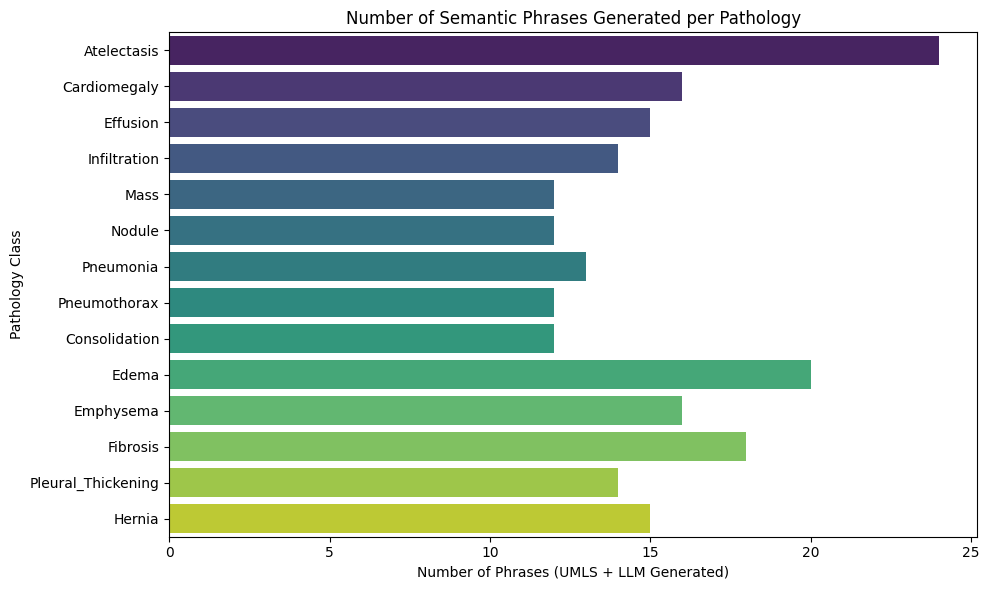

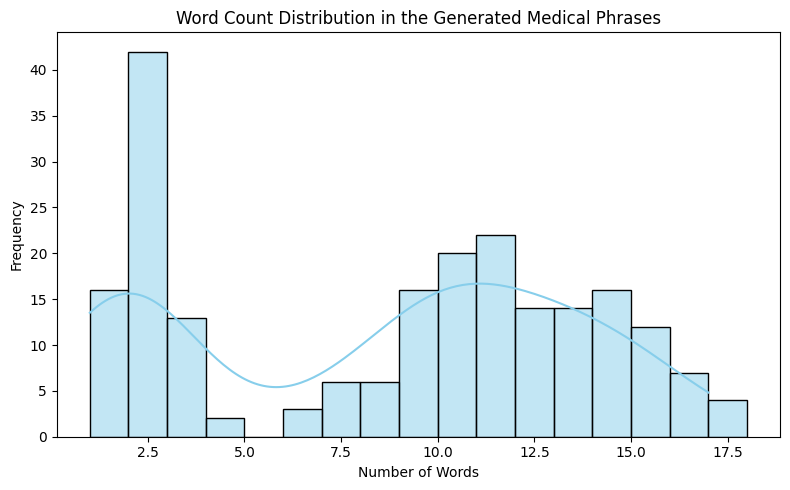

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Prepare data for plotting
labels = list(expanded_dictionary_dict.keys())
counts = [len(phrases) for phrases in expanded_dictionary_dict.values()]

# Plot 1: Number of Semantic Phrases Generated per Pathology
plt.figure(figsize=(10, 6))
sns.barplot(x=counts, y=labels, palette="viridis")
plt.title("Number of Semantic Phrases Generated per Pathology")
plt.xlabel("Number of Phrases (UMLS + LLM Generated)")
plt.ylabel("Pathology Class")
plt.tight_layout()
plt.show()

# Plot 2: Phrase Length Distribution
phrase_lengths = [len(phrase.split()) for phrase in medical_dictionary]
plt.figure(figsize=(8, 5))
sns.histplot(phrase_lengths, bins=range(1, max(phrase_lengths)+2), kde=True, color="skyblue")
plt.title("Word Count Distribution in the Generated Medical Phrases")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


## 6. Encoding and Exporting the $T$ Matrix
Finally, we translate the generated phrases into mathematical vectors using the PubMed CLIP Text Encoder. The resulting matrix ($T$) will be normalized and saved to be used in the Sparse Autoencoder training notebook.

In [13]:
import torch.nn.functional as F
from transformers import AutoProcessor, AutoModel

save_path = os.path.join(save_dir, 'medical_dictionary_embeddings.pt')

print("Loading pubmed-clip-vit-base-patch32...")
clip_model_id = "flaviagiammarino/pubmed-clip-vit-base-patch32"
clip_processor = AutoProcessor.from_pretrained(clip_model_id)
# Ensure device is defined (was defined in LLM cell, but redefining is safe)
device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model = AutoModel.from_pretrained(clip_model_id).to(device)
clip_model.eval()

print("Generating textual embeddings (T Matrix)...")
BATCH_SIZE = 64
all_text_embeddings = []

with torch.no_grad():
    for i in range(0, len(medical_dictionary), BATCH_SIZE):
        batch_texts = medical_dictionary[i : i+BATCH_SIZE]

        inputs = clip_processor(text=batch_texts, padding=True, truncation=True, max_length=77, return_tensors='pt')
        inputs = {k: v.to(device) for k, v in inputs.items()}

        text_outputs = clip_model.get_text_features(**inputs)

        # Immediate L2 Normalization, essential for subsequent Cosine Similarity calculation
        normalized_embeddings = F.normalize(text_outputs.pooler_output, p=2, dim=1)
        all_text_embeddings.append(normalized_embeddings.cpu())

# Final Concatenation
T_matrix = torch.cat(all_text_embeddings, dim=0)

torch.save({
    'embeddings': T_matrix,
    'concepts': medical_dictionary
}, save_path)

print(f"\nOperation completed successfully!")
print(f"T Matrix saved in: {save_path}")
print(f"T Matrix shape: {T_matrix.shape}")


Loading pubmed-clip-vit-base-patch32...


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/568 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.42k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Generating textual embeddings (T Matrix)...


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]


Operation completed successfully!
T Matrix saved in: /content/drive/MyDrive/xai-project5/results/02_dictionary_creation/medical_dictionary_embeddings.pt
T Matrix shape: torch.Size([213, 512])
